In [1]:
# ============================================================
# Question 7 - Feature Conditioning Computational Exercise
# Feature Selection for Naive Bayes using Forward Selection
# and Backward Elimination on TinyMNIST Dataset
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import time
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ============================================================
# Part 1: Loading the Data
# ============================================================
# If a zip file is uploaded, extract it first:
import zipfile
import os

# Upload the zip file
from google.colab import files
print("Please upload the TinyMNIST.zip file:")
uploaded = files.upload()

# Extract the files
with zipfile.ZipFile('TinyMNIST.zip', 'r') as zip_ref:
    zip_ref.extractall('TinyMNIST_extracted')

# Find the file paths
for root, dirs, file_list in os.walk('TinyMNIST_extracted'):
    for f in file_list:
        print(os.path.join(root, f))

Please upload the TinyMNIST.zip file:


Saving TinyMNIST.zip to TinyMNIST.zip
TinyMNIST_extracted/TinyMNIST/trainLabels.csv
TinyMNIST_extracted/TinyMNIST/trainData.csv
TinyMNIST_extracted/TinyMNIST/TinyMNIST_loader.py
TinyMNIST_extracted/TinyMNIST/testLabels.csv
TinyMNIST_extracted/TinyMNIST/testData.csv


In [4]:
# ============================================================
# Loading the Dataset
# ============================================================
# Adjust the path based on the output above
data_path = 'TinyMNIST_extracted/TinyMNIST/'

# Load the data
print("Loading data...")
X_train = pd.read_csv(data_path + 'trainData.csv', header=None).values
y_train = pd.read_csv(data_path + 'trainLabels.csv', header=None).values.ravel()
X_test = pd.read_csv(data_path + 'testData.csv', header=None).values
y_test = pd.read_csv(data_path + 'testLabels.csv', header=None).values.ravel()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Classes: {np.unique(y_train)}")
print(f"Number of samples per class in train: {np.bincount(y_train.astype(int))}")

Loading data...
X_train shape: (5000, 196)
y_train shape: (5000,)
X_test shape: (2500, 196)
y_test shape: (2500,)
Number of features: 196
Classes: [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
Number of samples per class in train: [522 564 503 539 445 429 513 520 482 483]


In [5]:
# ============================================================
# Part 2: CCR Computation Function
# ============================================================

def compute_ccr(X_train_subset, y_train, X_test_subset, y_test):
    """
    Compute CCR (Correct Classification Rate) using Naive Bayes

    CCR = (Number of Correct Predictions / Total Number of Samples) × 100
    """
    model = GaussianNB()
    model.fit(X_train_subset, y_train)
    y_pred = model.predict(X_test_subset)
    ccr = accuracy_score(y_test, y_pred) * 100
    return ccr

In [6]:
# ============================================================
# Part 3: Baseline - Using All Features
# ============================================================
print("=" * 60)
print("Baseline: Naive Bayes with All Features")
print("=" * 60)

baseline_ccr = compute_ccr(X_train, y_train, X_test, y_test)
print(f"CCR with all {X_train.shape[1]} features: {baseline_ccr:.2f}%")

Baseline: Naive Bayes with All Features
CCR with all 196 features: 50.68%


In [7]:
# ============================================================
# Part 4: Forward Selection
# ============================================================
print("\n" + "=" * 60)
print("Forward Selection")
print("=" * 60)

n_features = X_train.shape[1]
all_features = list(range(n_features))

selected_features_forward = []
remaining_features = list(all_features)
forward_history = []  # Store the history

best_overall_ccr_forward = 0
best_overall_features_forward = []

start_time = time.time()

for step in range(n_features):
    best_ccr = -1
    best_feature = None

    for feature in remaining_features:
        # Current feature set + candidate feature
        candidate_features = selected_features_forward + [feature]

        X_train_subset = X_train[:, candidate_features]
        X_test_subset = X_test[:, candidate_features]

        ccr = compute_ccr(X_train_subset, y_train, X_test_subset, y_test)

        if ccr > best_ccr:
            best_ccr = ccr
            best_feature = feature

    # Add the best feature
    selected_features_forward.append(best_feature)
    remaining_features.remove(best_feature)

    forward_history.append({
        'step': step + 1,
        'added_feature': best_feature,
        'num_features': len(selected_features_forward),
        'ccr': best_ccr,
        'selected_features': list(selected_features_forward)
    })

    # Save the best state
    if best_ccr > best_overall_ccr_forward:
        best_overall_ccr_forward = best_ccr
        best_overall_features_forward = list(selected_features_forward)

    print(f"Step {step+1:3d}: Added feature {best_feature:3d} | "
          f"Num features: {len(selected_features_forward):3d} | "
          f"CCR: {best_ccr:.2f}%")

    # If all features have been added, stop
    if len(remaining_features) == 0:
        break

elapsed_forward = time.time() - start_time
print(f"\nExecution time: {elapsed_forward:.1f} seconds")
print(f"\nBest CCR in Forward Selection: {best_overall_ccr_forward:.2f}%")
print(f"Number of selected features: {len(best_overall_features_forward)}")
print(f"Selected features: {best_overall_features_forward}")


Forward Selection
Step   1: Added feature  35 | Num features:   1 | CCR: 22.12%
Step   2: Added feature 102 | Num features:   2 | CCR: 30.88%
Step   3: Added feature  91 | Num features:   3 | CCR: 38.32%
Step   4: Added feature 106 | Num features:   4 | CCR: 45.08%
Step   5: Added feature 131 | Num features:   5 | CCR: 49.48%
Step   6: Added feature  89 | Num features:   6 | CCR: 53.48%
Step   7: Added feature  49 | Num features:   7 | CCR: 57.36%
Step   8: Added feature 104 | Num features:   8 | CCR: 60.80%
Step   9: Added feature  47 | Num features:   9 | CCR: 63.56%
Step  10: Added feature  65 | Num features:  10 | CCR: 65.20%
Step  11: Added feature 132 | Num features:  11 | CCR: 66.96%
Step  12: Added feature  63 | Num features:  12 | CCR: 68.80%
Step  13: Added feature  74 | Num features:  13 | CCR: 69.96%
Step  14: Added feature 133 | Num features:  14 | CCR: 71.64%
Step  15: Added feature  52 | Num features:  15 | CCR: 72.32%
Step  16: Added feature 162 | Num features:  16 | C

In [8]:
# ============================================================
# Part 5: Backward Elimination
# ============================================================
print("\n" + "=" * 60)
print("Backward Elimination")
print("=" * 60)

selected_features_backward = list(all_features)
backward_history = []

# CCR with all features
initial_ccr = compute_ccr(X_train, y_train, X_test, y_test)
backward_history.append({
    'step': 0,
    'removed_feature': None,
    'num_features': len(selected_features_backward),
    'ccr': initial_ccr,
    'selected_features': list(selected_features_backward)
})

best_overall_ccr_backward = initial_ccr
best_overall_features_backward = list(selected_features_backward)

start_time = time.time()

for step in range(n_features - 1):  # At least 1 feature must remain
    best_ccr = -1
    worst_feature = None

    for feature in selected_features_backward:
        # Feature set without the candidate feature to remove
        candidate_features = [f for f in selected_features_backward if f != feature]

        X_train_subset = X_train[:, candidate_features]
        X_test_subset = X_test[:, candidate_features]

        ccr = compute_ccr(X_train_subset, y_train, X_test_subset, y_test)

        if ccr > best_ccr:
            best_ccr = ccr
            worst_feature = feature

    # Remove the worst feature
    selected_features_backward.remove(worst_feature)

    backward_history.append({
        'step': step + 1,
        'removed_feature': worst_feature,
        'num_features': len(selected_features_backward),
        'ccr': best_ccr,
        'selected_features': list(selected_features_backward)
    })

    # Save the best state
    if best_ccr > best_overall_ccr_backward:
        best_overall_ccr_backward = best_ccr
        best_overall_features_backward = list(selected_features_backward)

    print(f"Step {step+1:3d}: Removed feature {worst_feature:3d} | "
          f"Remaining features: {len(selected_features_backward):3d} | "
          f"CCR: {best_ccr:.2f}%")

    # If only 1 feature remains, stop
    if len(selected_features_backward) <= 1:
        break

elapsed_backward = time.time() - start_time
print(f"\nExecution time: {elapsed_backward:.1f} seconds")
print(f"\nBest CCR in Backward Elimination: {best_overall_ccr_backward:.2f}%")
print(f"Number of selected features: {len(best_overall_features_backward)}")
print(f"Selected features: {best_overall_features_backward}")


Backward Elimination
Step   1: Removed feature  30 | Remaining features: 195 | CCR: 52.16%
Step   2: Removed feature  57 | Remaining features: 194 | CCR: 53.24%
Step   3: Removed feature 127 | Remaining features: 193 | CCR: 54.04%
Step   4: Removed feature  19 | Remaining features: 192 | CCR: 55.00%
Step   5: Removed feature 184 | Remaining features: 191 | CCR: 56.32%
Step   6: Removed feature 113 | Remaining features: 190 | CCR: 57.64%
Step   7: Removed feature 169 | Remaining features: 189 | CCR: 58.80%
Step   8: Removed feature  56 | Remaining features: 188 | CCR: 60.20%
Step   9: Removed feature  43 | Remaining features: 187 | CCR: 61.40%
Step  10: Removed feature  21 | Remaining features: 186 | CCR: 62.08%
Step  11: Removed feature  29 | Remaining features: 185 | CCR: 62.80%
Step  12: Removed feature 139 | Remaining features: 184 | CCR: 63.40%
Step  13: Removed feature  54 | Remaining features: 183 | CCR: 63.96%
Step  14: Removed feature  24 | Remaining features: 182 | CCR: 64.64

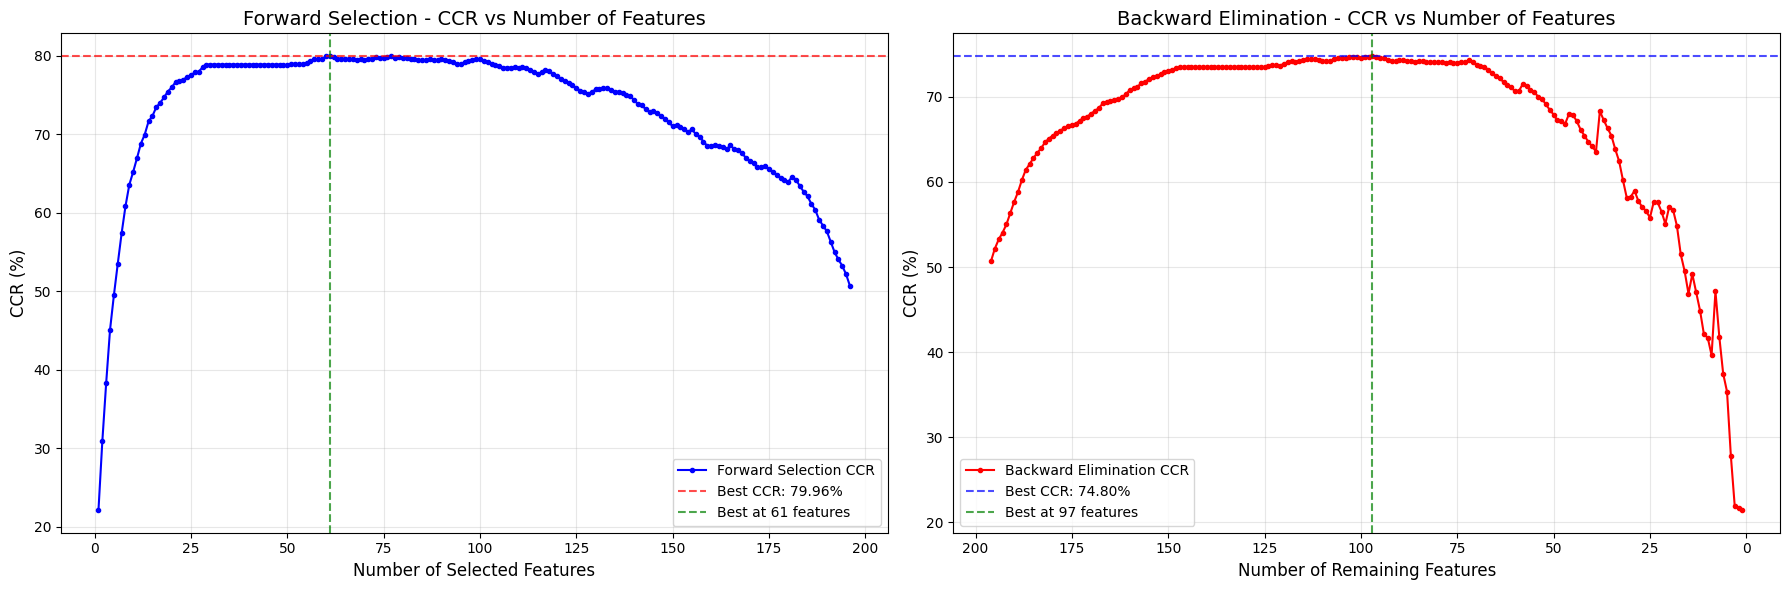

In [9]:
# ============================================================
# Part 6: Plotting the Results
# ============================================================

# Forward Selection and Backward Elimination Plots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Forward Selection Plot
forward_steps = [h['num_features'] for h in forward_history]
forward_ccrs = [h['ccr'] for h in forward_history]

axes[0].plot(forward_steps, forward_ccrs, 'b-o', markersize=3, linewidth=1.5, label='Forward Selection CCR')
axes[0].axhline(y=best_overall_ccr_forward, color='r', linestyle='--', alpha=0.7,
                label=f'Best CCR: {best_overall_ccr_forward:.2f}%')
best_idx_fwd = forward_ccrs.index(max(forward_ccrs))
axes[0].axvline(x=forward_steps[best_idx_fwd], color='g', linestyle='--', alpha=0.7,
                label=f'Best at {forward_steps[best_idx_fwd]} features')
axes[0].set_xlabel('Number of Selected Features', fontsize=12)
axes[0].set_ylabel('CCR (%)', fontsize=12)
axes[0].set_title('Forward Selection - CCR vs Number of Features', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Backward Elimination Plot
backward_steps = [h['num_features'] for h in backward_history]
backward_ccrs = [h['ccr'] for h in backward_history]

axes[1].plot(backward_steps, backward_ccrs, 'r-o', markersize=3, linewidth=1.5, label='Backward Elimination CCR')
axes[1].axhline(y=best_overall_ccr_backward, color='b', linestyle='--', alpha=0.7,
                label=f'Best CCR: {best_overall_ccr_backward:.2f}%')
best_idx_bwd = backward_ccrs.index(max(backward_ccrs))
axes[1].axvline(x=backward_steps[best_idx_bwd], color='g', linestyle='--', alpha=0.7,
                label=f'Best at {backward_steps[best_idx_bwd]} features')
axes[1].set_xlabel('Number of Remaining Features', fontsize=12)
axes[1].set_ylabel('CCR (%)', fontsize=12)
axes[1].set_title('Backward Elimination - CCR vs Number of Features', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].invert_xaxis()  # Invert x-axis

plt.tight_layout()
plt.savefig('feature_selection_results.png', dpi=150, bbox_inches='tight')
plt.show()

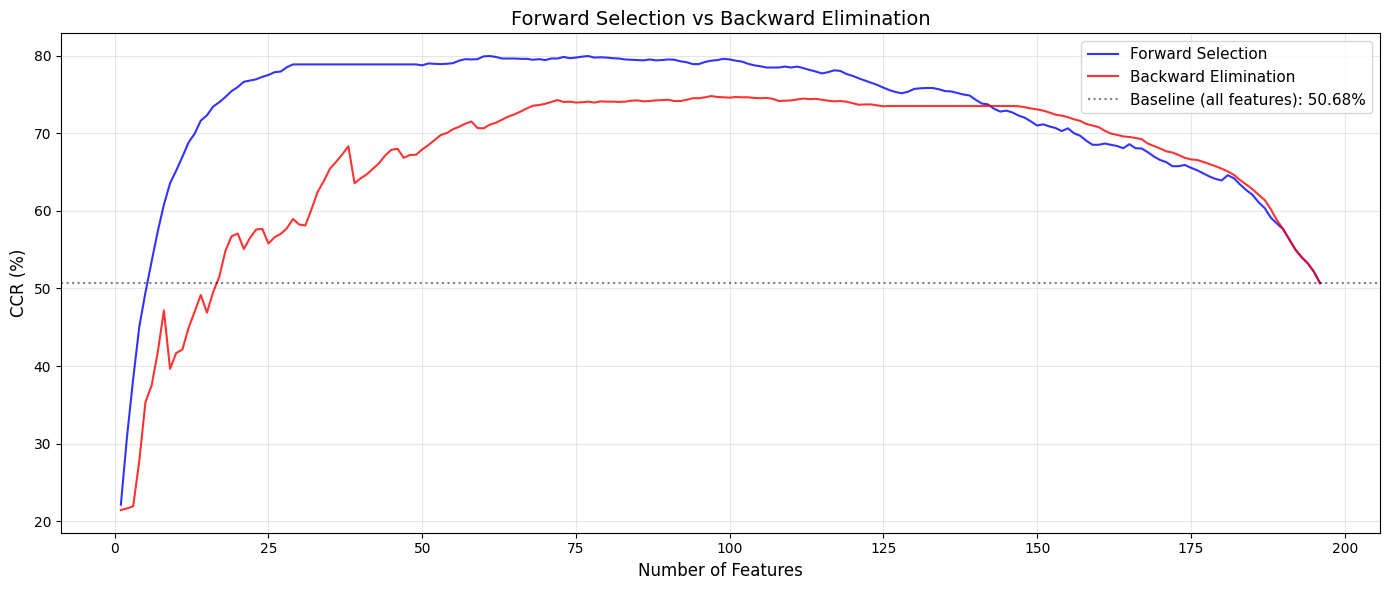

In [10]:
# ============================================================
# Part 7: Comparison of Both Methods
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(forward_steps, forward_ccrs, 'b-', linewidth=1.5, alpha=0.8, label='Forward Selection')
ax.plot(backward_steps, backward_ccrs, 'r-', linewidth=1.5, alpha=0.8, label='Backward Elimination')
ax.axhline(y=baseline_ccr, color='k', linestyle=':', alpha=0.5, label=f'Baseline (all features): {baseline_ccr:.2f}%')

ax.set_xlabel('Number of Features', fontsize=12)
ax.set_ylabel('CCR (%)', fontsize=12)
ax.set_title('Forward Selection vs Backward Elimination', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ============================================================
# Part 8: Summary Table of Results
# ============================================================
print("\n" + "=" * 70)
print("Summary Table of Results")
print("=" * 70)
print(f"{'Method':<30} {'Num Features':<15} {'CCR (%)':<10}")
print("-" * 55)
print(f"{'Baseline (All Features)':<30} {n_features:<15} {baseline_ccr:.2f}")
print(f"{'Forward Selection (Best)':<30} {len(best_overall_features_forward):<15} {best_overall_ccr_forward:.2f}")
print(f"{'Backward Elimination (Best)':<30} {len(best_overall_features_backward):<15} {best_overall_ccr_backward:.2f}")
print("=" * 55)

print(f"\n--- Forward Selection ---")
print(f"Best feature subset ({len(best_overall_features_forward)} features):")
print(f"{best_overall_features_forward}")
print(f"CCR: {best_overall_ccr_forward:.2f}%")

print(f"\n--- Backward Elimination ---")
print(f"Best feature subset ({len(best_overall_features_backward)} features):")
print(f"{best_overall_features_backward}")
print(f"CCR: {best_overall_ccr_backward:.2f}%")


Summary Table of Results
Method                         Num Features    CCR (%)   
-------------------------------------------------------
Baseline (All Features)        196             50.68
Forward Selection (Best)       61              79.96
Backward Elimination (Best)    97              74.80

--- Forward Selection ---
Best feature subset (61 features):
[35, 102, 91, 106, 131, 89, 49, 104, 47, 65, 132, 63, 74, 133, 52, 162, 135, 76, 77, 78, 144, 149, 116, 61, 118, 64, 90, 75, 148, 0, 1, 2, 3, 12, 13, 14, 15, 27, 28, 84, 98, 154, 167, 168, 181, 182, 183, 194, 195, 120, 51, 134, 147, 80, 101, 103, 46, 60, 79, 48, 146]
CCR: 79.96%

--- Backward Elimination ---
Best feature subset (97 features):
[7, 9, 11, 18, 20, 22, 23, 25, 26, 31, 34, 36, 37, 38, 39, 40, 44, 45, 46, 47, 48, 49, 50, 52, 53, 55, 60, 61, 63, 64, 66, 68, 69, 70, 71, 74, 75, 77, 79, 80, 82, 87, 88, 89, 90, 91, 92, 93, 95, 96, 97, 101, 102, 103, 104, 105, 106, 110, 116, 118, 120, 121, 126, 130, 131, 132, 134, 135, 136, 1

Image dimensions: 14x14 = 196 pixels


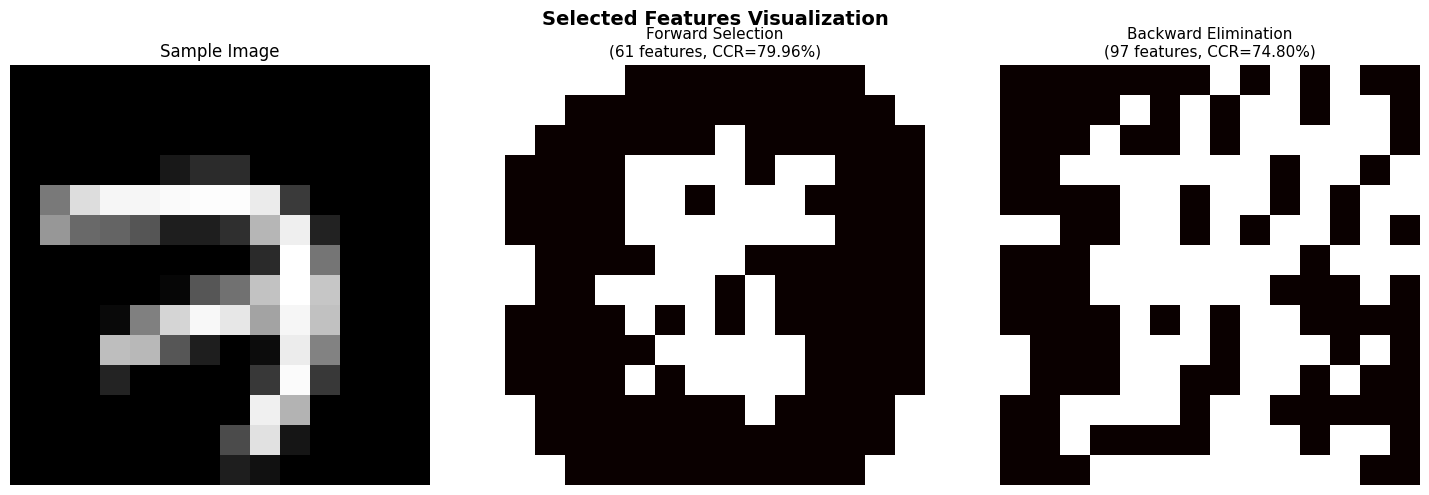

In [12]:
# ============================================================
# Part 9: Visualizing the Selected Features on the Image
# ============================================================

# Determine image dimensions
n_pixels = X_train.shape[1]
img_size = int(np.sqrt(n_pixels))
print(f"Image dimensions: {img_size}x{img_size} = {n_pixels} pixels")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Display a sample image
sample_img = X_train[0].reshape(img_size, img_size)
axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title('Sample Image', fontsize=12)
axes[0].axis('off')

# Forward Selection mask
mask_forward = np.zeros(n_pixels)
mask_forward[best_overall_features_forward] = 1
axes[1].imshow(mask_forward.reshape(img_size, img_size), cmap='hot')
axes[1].set_title(f'Forward Selection\n({len(best_overall_features_forward)} features, CCR={best_overall_ccr_forward:.2f}%)', fontsize=11)
axes[1].axis('off')

# Backward Elimination mask
mask_backward = np.zeros(n_pixels)
mask_backward[best_overall_features_backward] = 1
axes[2].imshow(mask_backward.reshape(img_size, img_size), cmap='hot')
axes[2].set_title(f'Backward Elimination\n({len(best_overall_features_backward)} features, CCR={best_overall_ccr_backward:.2f}%)', fontsize=11)
axes[2].axis('off')

plt.suptitle('Selected Features Visualization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('selected_features_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ============================================================
# Part 10: Forward Selection Steps Table (First 20 Steps)
# ============================================================
print("\n--- Forward Selection Steps (First 20) ---")
print(f"{'Step':<6} {'Added Feature':<16} {'Num Features':<15} {'CCR (%)':<10}")
print("-" * 47)
for h in forward_history[:20]:
    print(f"{h['step']:<6} {h['added_feature']:<16} {h['num_features']:<15} {h['ccr']:.2f}")

print(f"\n--- Backward Elimination Steps (First 20) ---")
print(f"{'Step':<6} {'Removed Feature':<18} {'Num Features':<15} {'CCR (%)':<10}")
print("-" * 49)
for h in backward_history[:21]:
    removed = h['removed_feature'] if h['removed_feature'] is not None else '-'
    print(f"{h['step']:<6} {str(removed):<18} {h['num_features']:<15} {h['ccr']:.2f}")


--- Forward Selection Steps (First 20) ---
Step   Added Feature    Num Features    CCR (%)   
-----------------------------------------------
1      35               1               22.12
2      102              2               30.88
3      91               3               38.32
4      106              4               45.08
5      131              5               49.48
6      89               6               53.48
7      49               7               57.36
8      104              8               60.80
9      47               9               63.56
10     65               10              65.20
11     132              11              66.96
12     63               12              68.80
13     74               13              69.96
14     133              14              71.64
15     52               15              72.32
16     162              16              73.44
17     135              17              74.00
18     76               18              74.68
19     77               19   